Jasper Lim 917038
John Buni 
Eche Oji 

# PROG8431 – Solutions to  Highway Congestion​

Our problem concerns traffic congestion on provincial roads and highways in Southern Ontario. Congestion affects travel time, road efficiency, and the movement of people and goods. To investigate the problem, we identified publicly available transportation datasets from the Ontario Ministry of Transportation, Ontario Open Data, and 511 Ontario. These datasets provide historical traffic volumes, road information, traffic patterns, and related variables that can support analysis and machine learning. ​
​
**Our research question is: What factors contribute to highway congestion in Southern Ontario, and can historical traffic data be used to predict periods of high congestion, or identify alternative routes to aid decongestion? Future work could incorporate real-time traffic and incident data.​**

## Will it be one-time or ongoing?​

Ongoing. Ontario 511 provides real-time and static transportation data, while the Ontario Incidents and Closures dataset is described as containing up-to-date active events on provincially owned and maintained highways. https://511on.ca/developers/resources https://data.ontario.ca/dataset/incidents-and-closures​
​
## Will it be automated?​

Yes. Ontario 511 provides a REST API, so a program can request transportation data automatically. The API documentation also states that throttling is enabled at 10 calls every 60 seconds.​
​
## How can we track it?​

By storing repeated API responses with timestamps, roadway, direction, event type, location, and other available fields, then comparing traffic events over time and across highway segments. ​



In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib_venn import venn2

data = pd.read_excel('Provincial Highways Traffic Volumes 2024 AADT Only.xlsx')


d. Uses at least one markup cell to describe how it needs to undergo cleansing before it can be used during a Data Analysis experiment. Use the information in slides 22 and 23 in the Unit 1 class notes as a guide. 

There are a few empty rows that have been used as separators between highways. We can use dataframe's .dropna() to remove these empty rows.

In [10]:
data.dropna()

,Highway,Location Description From,Location Description To,Distance (KM),2024 AADT
0,QEW,FORT ERIE-GODERICH ST-PEACE BRIDGE PLAZA,CENTRAL AV IC,0.230,13400.0
1,QEW,CENTRAL AV IC,CONCESSION RD IC-1,0.933,19100.0
2,QEW,CONCESSION RD IC-1,THOMPSON RD IC-2,1.045,18300.0
3,QEW,THOMPSON RD IC-2,GILMORE RD IC-5,2.450,22600.0
4,QEW,GILMORE RD IC-5,BOWEN RD IC-7,2.059,26300.0
...,...,...,...,...,...
2702,7908,START HOWARD AVE DIVERSION AT SOUTH TALBOT RD,HOWARD AVE CONNECTOR,0.430,11000.0
2703,7908,HOWARD AVE CONNECTOR,HWY 3/HWY 401 ROUNDABOUT - END OF HWY 7908,0.520,9800.0
2706,7909,START OF HWY 7909,HWY 7910 AVRO ARROW RD/69 IC,3.500,2150.0
2707,7909,HWY 7910 AVRO ARROW RD/69 IC,END OF HWY 7909 - HWY 69,2.640,1050.0


From Challenge 3 - Understand the collected data and explain it in 1 minute

The data contains around 1800 entries which detail subsections of the Ontario provincial highway system, their length, and their AADT (average annual daily traffic.)

From Challenge 4 - Encapsulate the code in classes, methods 

From Challenge 5 - Calculate the mean, median, and mode in a way that makes sense 

In [11]:
length = data["Distance (KM)"]
aadt = data["2024 AADT"]

print("Total distance mode(s) \n",length.mode())
print("Total average distance ",length.mean())
print("Total median distance ",length.median())

print("Total AADT mode(s) \n",aadt.mode())
print("Total average AADT ",aadt.mean())
print("Total median AADT ",aadt.median())

print("Average distance by highway ",data.groupby("Highway")["Distance (KM)"].mean().mean().copy())
print("Average AADT by highway ",data.groupby("Highway")["2024 AADT"].mean().mean().copy())

Total distance mode(s) 
 0    2.7
Name: Distance (KM), dtype: float64
Total average distance  9.124927653498334
Total median distance  4.736000000000004
Total AADT mode(s) 
 0    1050.0
1    1650.0
2    1900.0
3    3600.0
4    8450.0
Name: 2024 AADT, dtype: float64
Total average AADT  31808.32044198895
Total median AADT  7350.0
Average distance by highway  11.204256643543737
Average AADT by highway  8692.3222361812


From Challenge 6 - Calculate the variance standard deviation and four Quartiles in a way that makes sense


In [12]:
print("Distance Variance:", length.var())
print("Distance Standard Deviation:", length.std())
print("AADT Variance:", aadt.var())
print("AADT Standard Deviation:", aadt.std())

print("Distance Quartiles:\n", length.quantile([0.25, 0.50, 0.75, 1.00]))
print("AADT Quartiles:\n", aadt.quantile([0.25, 0.50, 0.75, 1.00]))



Distance Variance: 192.22062239095396
Distance Standard Deviation: 13.864365199710875
AADT Variance: 4450535012.1029
AADT Standard Deviation: 66712.33028535954
Distance Quartiles:
 0.25      2.070
0.50      4.736
0.75     10.200
1.00    178.600
Name: Distance (KM), dtype: float64
AADT Quartiles:
 0.25      2012.5
0.50      7350.0
0.75     23500.0
1.00    511400.0
Name: 2024 AADT, dtype: float64


In [14]:

distancestats = data.groupby("Highway")["Distance (KM)"].agg(
    variance="var",
    std="std"
)

aadtstats = data.groupby("Highway")["2024 AADT"].agg(
    variance="var",
    std="std"
)

print(distancestats)
print(aadtstats)

           variance        std
Highway                       
2        417.027200  20.421244
3        320.769390  17.910036
4         34.534918   5.876642
5        211.838080  14.554658
6         55.543807   7.452772
...             ...        ...
560A            NaN        NaN
58A        6.294152   2.508815
607A            NaN        NaN
7A        31.184077   5.584270
QEW        2.480902   1.575088

[305 rows x 2 columns]
             variance           std
Highway                            
2                 NaN           NaN
3        7.924289e+07   8901.847538
4        9.143942e+06   3023.895221
5        4.702500e+07   6857.477670
6        1.822947e+08  13501.656656
...               ...           ...
560A              NaN           NaN
58A      4.512500e+05    671.751442
607A              NaN           NaN
7A       2.363187e+07   4861.262696
QEW      4.737791e+09  68831.609862

[305 rows x 2 columns]


From Challenge 7 - Display the data with a scatter plot, a histogram, a box-whisker plot, and a Venn Diagram 

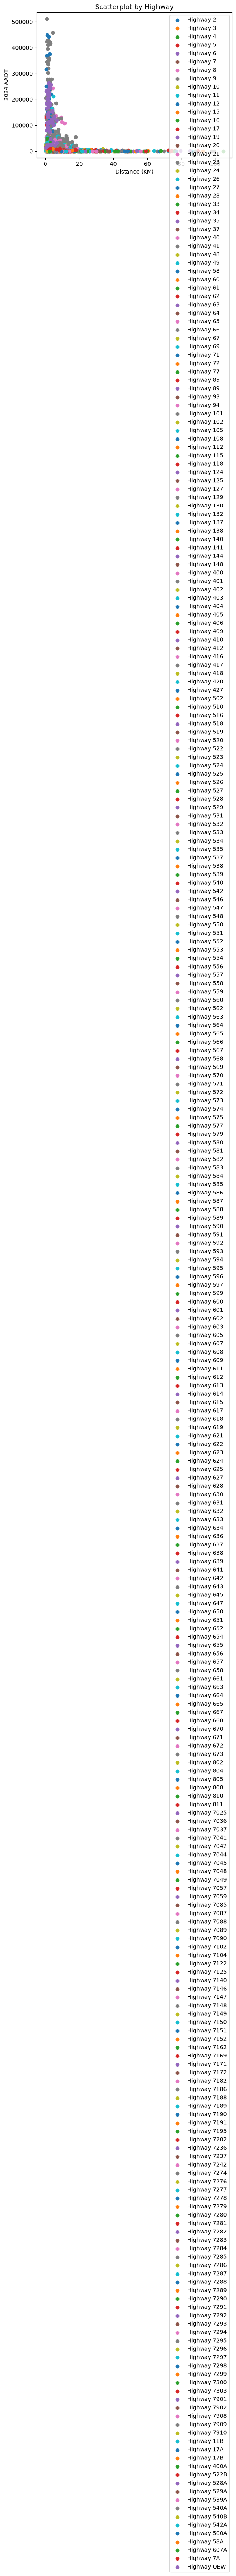

In [6]:

for group, data in data.groupby("Highway"):
    plt.scatter(
        data["Distance (KM)"],          # x-axis column
        data["2024 AADT"],     # y-axis column
        label=f"Highway {group}"
    )

plt.xlabel("Distance (KM)")
plt.ylabel("2024 AADT")
plt.title("Scatterplot by Highway")
plt.legend()
plt.show()

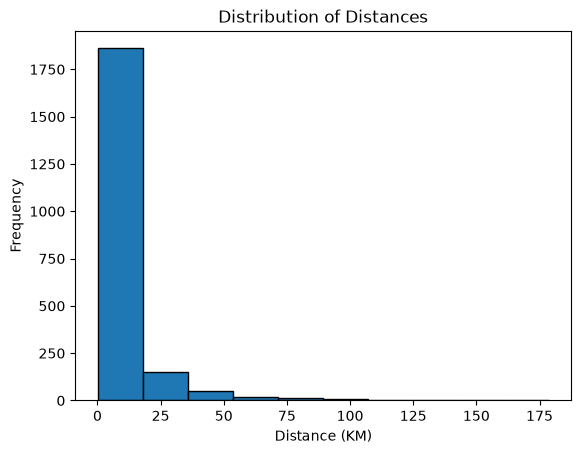

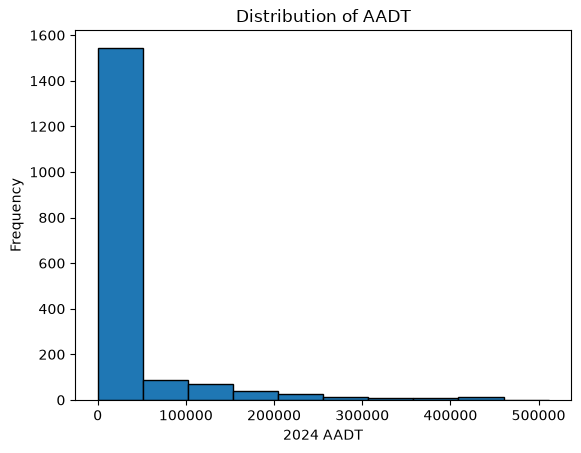

In [16]:
plt.hist(data["Distance (KM)"].dropna(), bins=10, edgecolor="black")
plt.xlabel("Distance (KM)")
plt.ylabel("Frequency")
plt.title("Distribution of Distances")
plt.show()

plt.hist(data["2024 AADT"].dropna(), bins=10, edgecolor="black")
plt.xlabel("2024 AADT") 
plt.ylabel("Frequency")
plt.title("Distribution of AADT")
plt.show()

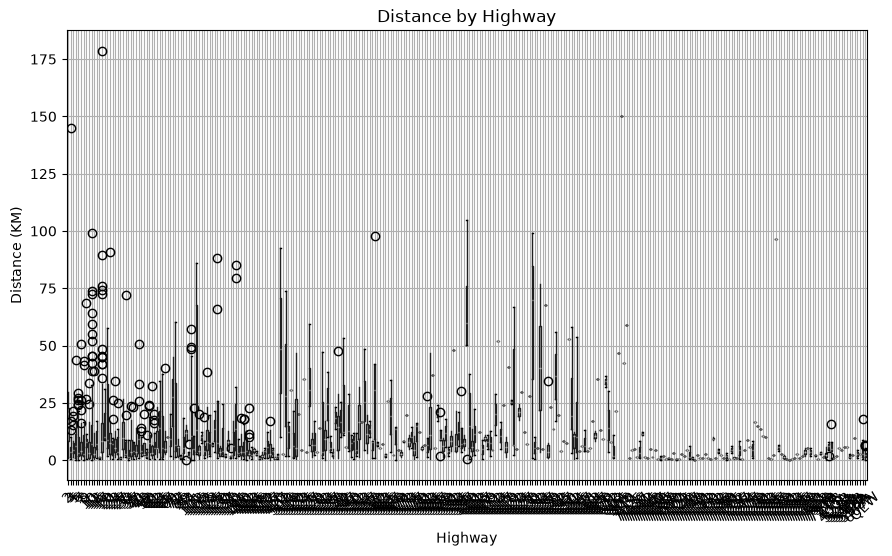

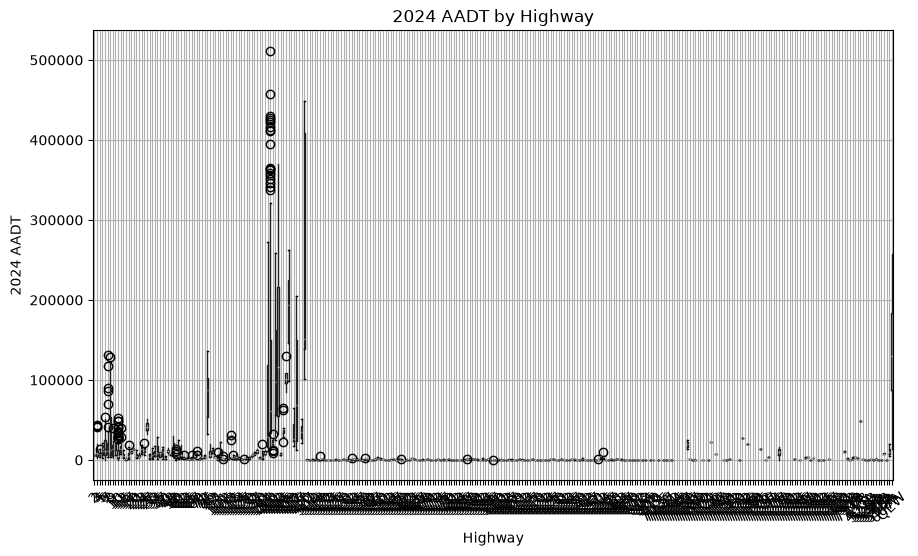

In [17]:
# Boxplot for Distance
data.boxplot(column="Distance (KM)", by="Highway", figsize=(10, 6))
plt.title("Distance by Highway")
plt.suptitle("")
plt.xlabel("Highway")
plt.ylabel("Distance (KM)")
plt.xticks(rotation=45)
plt.show()

# Boxplot for AADT
data.boxplot(column="2024 AADT", by="Highway", figsize=(10, 6))
plt.title("2024 AADT by Highway")
plt.suptitle("")
plt.xlabel("Highway")
plt.ylabel("2024 AADT")
plt.xticks(rotation=45)
plt.show()

In [20]:
# likely no sensible Venn diagram for this data.

From Challenge 7 - Present a numerical summary of the data

In [21]:
print(data.describe())

       Distance (KM)      2024 AADT
count    2101.000000    1810.000000
mean        9.124928   31808.320442
std        13.864365   66712.330285
min         0.100000      10.000000
25%         2.070000    2012.500000
50%         4.736000    7350.000000
75%        10.200000   23500.000000
max       178.600000  511400.000000
